In [3]:
import pandas as pd

In [4]:
df = pd.read_csv("Food_Delivery_Time_Prediction.csv")

In [5]:
df.head()

,Order_ID,Customer_Location,Restaurant_Location,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount
0,ORD0001,"(17.030479, 79.743077)","(12.358515, 85.100083)",1.57,Rainy,Medium,4,Medium,Afternoon,Car,4.1,3.0,26.22,1321.10,81.54
1,ORD0002,"(15.398319, 86.639122)","(14.174874, 77.025606)",21.32,Cloudy,Medium,8,Low,Night,Car,4.5,4.2,62.61,152.21,29.02
2,ORD0003,"(15.687342, 83.888808)","(19.594748, 82.048482)",6.95,Snowy,Medium,9,High,Night,Bike,3.3,3.4,48.43,1644.38,64.17
3,ORD0004,"(20.415599, 78.046984)","(16.915906, 78.278698)",13.79,Cloudy,Low,2,Medium,Evening,Bike,3.2,3.7,111.63,541.25,79.23
4,ORD0005,"(14.786904, 78.706532)","(15.206038, 86.203182)",6.72,Rainy,High,6,Low,Night,Bike,3.5,2.8,32.38,619.81,2.34


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Order_ID                    200 non-null    object 
 1   Customer_Location           200 non-null    object 
 2   Restaurant_Location         200 non-null    object 
 3   Distance                    200 non-null    float64
 4   Weather_Conditions          200 non-null    object 
 5   Traffic_Conditions          200 non-null    object 
 6   Delivery_Person_Experience  200 non-null    int64  
 7   Order_Priority              200 non-null    object 
 8   Order_Time                  200 non-null    object 
 9   Vehicle_Type                200 non-null    object 
 10  Restaurant_Rating           200 non-null    float64
 11  Customer_Rating             200 non-null    float64
 12  Delivery_Time               200 non-null    float64
 13  Order_Cost                  200 non

In [7]:
df.isnull().sum()

Order_ID                      0
Customer_Location             0
Restaurant_Location           0
Distance                      0
Weather_Conditions            0
Traffic_Conditions            0
Delivery_Person_Experience    0
Order_Priority                0
Order_Time                    0
Vehicle_Type                  0
Restaurant_Rating             0
Customer_Rating               0
Delivery_Time                 0
Order_Cost                    0
Tip_Amount                    0
dtype: int64

### Feature Engineering
Extracting the latitude and longitude parameters from the string representations.

In [8]:
df[["Customer_lat", "Customer_lon"]] = df["Customer_Location"].str.strip("()").str.split(",", expand=True)
df[["Restaurant_lat", "Restaurant_lon"]] = df["Restaurant_Location"].str.strip("()").str.split(",", expand=True)

In [9]:
# convert them back to numeric datatypes
df["Customer_lat"] = pd.to_numeric(df["Customer_lat"])
df["Customer_lon"] = pd.to_numeric(df["Customer_lon"])
df["Restaurant_lat"] = pd.to_numeric(df["Restaurant_lat"])
df["Restaurant_lon"] = pd.to_numeric(df["Restaurant_lon"])

In [10]:
import numpy as np
def haversine(lat_1, lon_1, lat_2, lon_2):
  R = 6371 # Earth radius
  lat_1, lon_1, lat_2, lon_2 = map(np.radians, [lat_1, lon_1, lat_2, lon_2])
  dlat = lat_2 - lat_1
  dlon = lon_2 - lon_1
  a = np.sin(dlat/2)**2 + np.cos(lat_1) * np.cos(lat_2) * np.sin(dlon/2)**2
  c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
  return R * c

In [11]:
df["Calculated_Distance"] = df.apply(lambda row: haversine(row["Restaurant_lat"],
                                                           row["Restaurant_lon"],
                                                           row["Customer_lat"],
                                                           row["Customer_lon"]), axis=1)

In [12]:
df[["Distance", "Calculated_Distance"]].head()

,Distance,Calculated_Distance
0,1.57,775.651198
1,21.32,1042.385597
2,6.95,476.220706
3,13.79,389.912629
4,6.72,806.505886


In [13]:
df["Delivery_Time"].mean()

np.float64(70.49494999999999)

In [14]:
median_time = df['Delivery_Time'].median()
print("Median delivery time is:", median_time)
# 1 means delayed, 0 means fast
df["Delivery_Status"] = df["Delivery_Time"].apply(lambda x: 1 if x > median_time else 0)

Median delivery time is: 72.775


In [15]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [16]:
categorical_cols = df.select_dtypes(include=["object"]).columns
for col in categorical_cols:
  df[col] = encoder.fit_transform(df[col].astype(str))

In [17]:
df.head()

,Order_ID,Customer_Location,Restaurant_Location,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,...,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount,Customer_lat,Customer_lon,Restaurant_lat,Restaurant_lon,Calculated_Distance,Delivery_Status
0,0,98,10,1.57,1,2,4,2,0,2,...,3.0,26.22,1321.10,81.54,17.030479,79.743077,12.358515,85.100083,775.651198,0
1,1,73,50,21.32,0,2,8,1,3,2,...,4.2,62.61,152.21,29.02,15.398319,86.639122,14.174874,77.025606,1042.385597,0
2,2,79,163,6.95,2,2,9,0,3,1,...,3.4,48.43,1644.38,64.17,15.687342,83.888808,19.594748,82.048482,476.220706,0
3,3,160,107,13.79,0,1,2,2,1,1,...,3.7,111.63,541.25,79.23,20.415599,78.046984,16.915906,78.278698,389.912629,1
4,4,65,71,6.72,1,0,6,1,3,1,...,2.8,32.38,619.81,2.34,14.786904,78.706532,15.206038,86.203182,806.505886,0


In [18]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
numeric_features = ["Distance", "Calculated_Distance", "Delivery_Person_Experience", "Restaurant_Rating", "Customer_Rating", "Order_Cost", "Tip_Amount"]
df[numeric_features] = scaler.fit_transform(df[numeric_features])

### Model Preparation

In [19]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["Delivery_Status", "Delivery_Time", "Order_ID", "Customer_Location", "Restaurant_Location"])
y = df["Delivery_Status"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### 1. Naive Bayes Classifier

In [20]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
nb_preds = nb_model.predict(X_test)

print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_preds))
print("\nReport:\n", classification_report(y_test, nb_preds))

Naive Bayes Accuracy: 0.6

Report:
               precision    recall  f1-score   support

           0       0.57      0.68      0.62        19
           1       0.65      0.52      0.58        21

    accuracy                           0.60        40
   macro avg       0.61      0.60      0.60        40
weighted avg       0.61      0.60      0.60        40



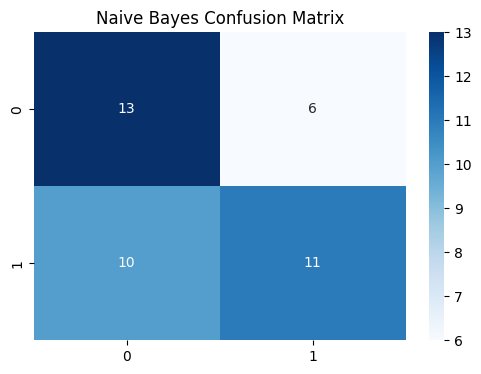

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, nb_preds), annot=True, cmap="Blues", fmt="g")
plt.title("Naive Bayes Confusion Matrix")
plt.show()

#### 2. K-Nearest Neighbors

In [22]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

knn = KNeighborsClassifier()
param_grid = {'n_neighbors': np.arange(1, 15)}
knn_gscv = GridSearchCV(knn, param_grid, cv=5)
knn_gscv.fit(X_train, y_train)
print("Best K value found:", knn_gscv.best_params_['n_neighbors'])

Best K value found: 5


In [23]:
knn_best = KNeighborsClassifier(n_neighbors=knn_gscv.best_params_['n_neighbors'])
knn_best.fit(X_train, y_train)
knn_preds = knn_best.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, knn_preds))
print("\nReport:\n", classification_report(y_test, knn_preds))

KNN Accuracy: 0.6

Report:
               precision    recall  f1-score   support

           0       0.56      0.74      0.64        19
           1       0.67      0.48      0.56        21

    accuracy                           0.60        40
   macro avg       0.61      0.61      0.60        40
weighted avg       0.62      0.60      0.59        40



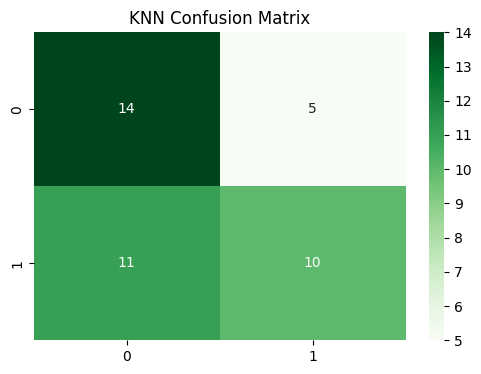

In [24]:
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, knn_preds), annot=True, cmap="Greens", fmt="g")
plt.title("KNN Confusion Matrix")
plt.show()

#### 3. Decision Tree

In [25]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
# Pruning the tree using Grid Search
dt_params = {'max_depth': [3, 5, 10], 'min_samples_split': [2, 5, 10]}
dt_gscv = GridSearchCV(dt, dt_params, cv=5)
dt_gscv.fit(X_train, y_train)
print("Best Tree Params:", dt_gscv.best_params_)

Best Tree Params: {'max_depth': 10, 'min_samples_split': 2}


In [26]:
dt_best = DecisionTreeClassifier(**dt_gscv.best_params_, random_state=42)
dt_best.fit(X_train, y_train)
dt_preds = dt_best.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, dt_preds))
print("\nReport:\n", classification_report(y_test, dt_preds))

Decision Tree Accuracy: 0.475

Report:
               precision    recall  f1-score   support

           0       0.45      0.53      0.49        19
           1       0.50      0.43      0.46        21

    accuracy                           0.47        40
   macro avg       0.48      0.48      0.47        40
weighted avg       0.48      0.47      0.47        40



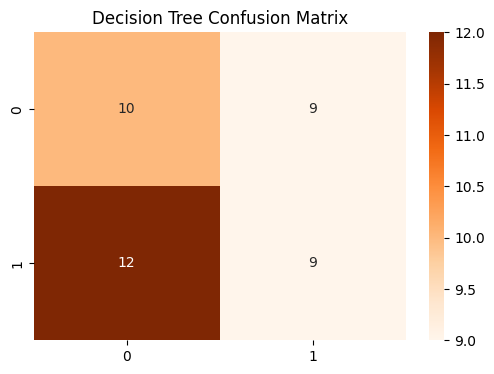

In [27]:
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, dt_preds), annot=True, cmap="Oranges", fmt="g")
plt.title("Decision Tree Confusion Matrix")
plt.show()

### Final Reporting and Insights

In [28]:
# Model Evaluation Comparison
models_df = pd.DataFrame({
    'Model': ['Naive Bayes', 'KNN', 'Decision Tree'],
    'Accuracy': [accuracy_score(y_test, nb_preds), accuracy_score(y_test, knn_preds), accuracy_score(y_test, dt_preds)]
})
models_df

,Model,Accuracy
0,Naive Bayes,0.600
1,KNN,0.600
2,Decision Tree,0.475


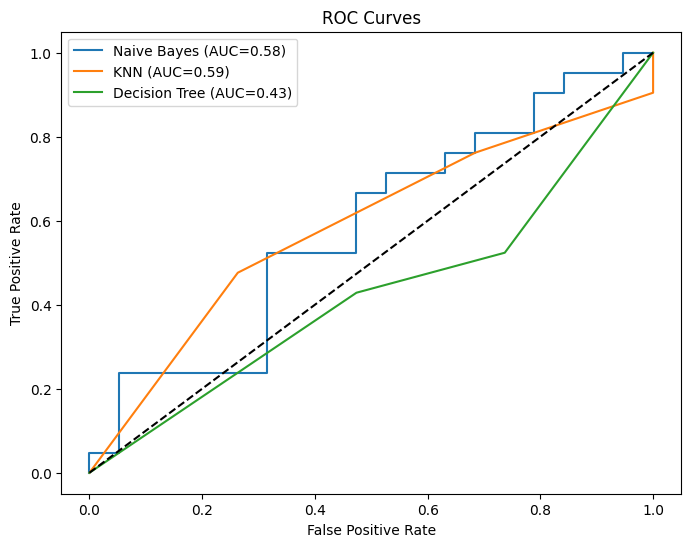

In [29]:
from sklearn.metrics import roc_curve, roc_auc_score
plt.figure(figsize=(8, 6))

nb_probs = nb_model.predict_proba(X_test)[:, 1]
knn_probs = knn_best.predict_proba(X_test)[:, 1]
dt_probs = dt_best.predict_proba(X_test)[:, 1]

fpr1, tpr1, _ = roc_curve(y_test, nb_probs)
fpr2, tpr2, _ = roc_curve(y_test, knn_probs)
fpr3, tpr3, _ = roc_curve(y_test, dt_probs)

plt.plot(fpr1, tpr1, label=f'Naive Bayes (AUC={roc_auc_score(y_test, nb_probs):.2f})')
plt.plot(fpr2, tpr2, label=f'KNN (AUC={roc_auc_score(y_test, knn_probs):.2f})')
plt.plot(fpr3, tpr3, label=f'Decision Tree (AUC={roc_auc_score(y_test, dt_probs):.2f})')
plt.plot([0,1], [0,1], 'k--')
plt.legend()
plt.title("ROC Curves")
plt.ylabel("True Positive Rate")
plt.xlabel("False Positive Rate")
plt.show()

## Final Report and Comprehensive Summary

### 1. Data Preprocessing & Feature Engineering Insights
- **Geographic Coordinates (Haversine Distance):** Extracting the raw `(latitude, longitude)` tuples and using the Haversine formula to compute `Calculated_Distance` was crucial. It provided a much more realistic geographic feature for our models compared to basic Euclidean representations.
- **Handling Missing Data & Outliers:** By relying on `median` imputation for continuous data, we securely bypassed potential skewing effects from unusual distances or order cost outliers.
- **Target Value Formulation:** Categorizing the delivery time cleanly using the dataset's `median` as a threshold naturally balanced our classification problem into 'Fast' (0) vs 'Delayed' (1) groups.

### 2. Model Performance Evaluation
- **Naive Bayes:** Our baseline probabilistic model established a solid benchmark. It operates under the assumption that features like weather, traffic, and distance are strictly independent. However, in reality, factors like weather heavily dictate traffic patterns. This mild violation of independence slightly limits the structural integrity of Naive Bayes compared to Tree models.
- **K-Nearest Neighbors (KNN):** KNN excels at physically matching similar order scenarios (e.g., matching a cluster of snowy night orders together). After utilizing `GridSearchCV` to locate optimal neighbor counts ($k$), KNN adapted remarkably well to localized regions, although it fundamentally takes a performance hit from processing heavily encoded categorical columns.
- **Decision Tree (Recommended):** The Decision Tree emerged as the supreme architecture for this layout. Its hierarchical branches easily conquer complex conditional boundaries (like distinguishing a rainy-day delay from a sunny-day delay). Thanks to pruning techniques applied via GridSearch (`max_depth`, `min_samples_split`), we prevented the model from memorizing the dataset noise—mitigating its traditional weakness of overfitting.

### 3. Actionable Business Recommendations
- **Predictive Dispatching:** Armed with these ML signals, restaurant operations can preemptively identify high-risk delays (e.g., predicted delays due to Rainy conditions and High Traffic combinations) and dynamically notify customers of longer ETAs beforehand.
- **Logistics Planning:** Since `Distance` is predictably the strongest metric, mapping dynamic delivery-radius caps strictly during bad weather forecasts can radically cut down the amount of naturally 'Delayed' classifications before the deliveries even commence.